# Request & Grant Deadlines (p. 13)

Expressions $e_{T_i}$, $e_\mathcal{T}$, $e'_\mathcal{T}$, $e''_\mathcal{T}$ constructed from a deadline list (eqs 20–23).
Volume curves and scaling plot for $e''_\mathcal{T}$.

In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import sys, os, time, random
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": [],
    "font.weight": "normal",
    "figure.dpi": 110,
})

def _find_repo_root():
    try:
        d = os.path.abspath(os.getcwd())
    except (FileNotFoundError, OSError):
        d = '/workspace'
    while True:
        if os.path.isfile(os.path.join(d, "parse", "quickparse.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("repo root not found")
        d = parent

REPO = _find_repo_root()
for p in [REPO, os.path.join(REPO, "experiments", "paper_experiments")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from parse.quickparse import quickparse
from sample.sample import sample
from volume.slice_volume import slice_volume

random.seed(42); np.random.seed(42)

RESULTS = os.path.join(REPO, "experiments", "paper_experiments",
                       "12_page13_casestudy", "results")
os.makedirs(RESULTS, exist_ok=True)

# Quick smoke test
_phi = quickparse("<a>_[0,1] *", string=True)
_w   = sample(_phi, 3)
print("VolTRE OK:", _w)


VolTRE OK: (0.389, a),(0.816, a),(0.485, a)


### Setting

There are $k$ request types $r_1, \ldots, r_k$ with deadlines
$T_1 \le T_2 \le \cdots \le T_k$.
A shared grant event $g$ must answer each $r_i$ within $T_i$ time units.
In each cycle a single $g$ answers all pending requests;
any subset of request types may arrive before the grant.

### The four expressions

| Eq | Name | Meaning | VolTRE |
|---|---|---|---|
| (20) | $e_{T_i}$ | One type $r_i$, answered by $g$ within $T_i$ | ✓ volume + sample |
| (21) | $e_\mathcal{T} = \bigcap_i e_{T_i}$ | All $k$ types simultaneously | ⚠ sample only (intersection budget); no volume |
| (22) | $e'_\mathcal{T}$ | Ordered cycle: $r_1{\to}g{\to}r_2{\to}g{\to}\cdots$, $2k$ events | ✗ no analytic volume; sampling degenerates for $k\ge 2$ |
| (23) | $e''_\mathcal{T}$ | Nested: $(r_k?)\cdots(r_1?){\cdot}g$, optional requests, 1 shared grant | ✓ volume + sample, **1 TA clock** |

The key result of eq 23: $e''_\mathcal{T}$ uses only **1 clock** in its TA encoding
regardless of $k$, while a TA encoding of $e'_\mathcal{T}$ needs $k$ clocks.


In [2]:
def build_e_single(r, T):
    # eq 20: r_i always answered by g within T_i.
    s = f"(<{r} . g>_[0,{T}]) *"
    return quickparse(s, string=True), s

def build_e_T(deadlines):
    # eq 21: e_T = intersection of all e_{T_i}.
    # VolTRE can SAMPLE from this (rejection budget) but cannot compute its volume
    # (slice_volume raises ValueError for & subexpressions).
    parts = [f"((<{r} . g>_[0,{T}]) *)" for r, T in deadlines]
    s = " & ".join(parts)
    return quickparse(s, string=True), s

def build_e_prime(deadlines):
    # eq 22: e'_T = e_T & ((EPS + r_Tk) . ... . (EPS + r_T1) . g)*
    # Same optional-request body as e''_T but without nested timing.
    # Timing is enforced by the intersection with e_T.
    # Hard to sample (multiple intersections); no analytic volume.
    #
    # Structured as right-fold: e_T1 & (e_T2 & (... & kleene))
    # so that sample() always sees a plain Kleene as child1 (needed for
    # disambiguate), while match() handles the nested intersections in child2.
    body = " . ".join(f"(EPS + {r})" for r, T in reversed(deadlines))
    s = f"({body} . g) *"
    for r, T in reversed(deadlines):  # wrap from Tk down to T1 so T1 is outermost
        s = f"((<{r} . g>_[0,{T}]) *) & ({s})"
    return quickparse(s, string=True), s

def build_e_dprime(deadlines):
    # eq 23: nested timed, requests optional via EPS.
    # Each cycle: (EPS + r_k) . ... . (EPS + r_1) . g
    # At most k+1 events per cycle; g is the single shared grant.
    # Uses only 1 clock in the TA encoding, regardless of k.
    r1, T1 = deadlines[0]
    inner = f"<(EPS + {r1}) . g>_[0,{T1}]"
    for r_i, T_i in deadlines[1:]:
        inner = f"<(EPS + {r_i}) . {inner}>_[0,{T_i}]"
    s = f"({inner}) *"
    return quickparse(s, string=True), s

We use arithmetic deadlines $T_i = i$ for $i = 1, 2, \ldots, k$,
so the example generalises directly to any $k$.


In [3]:
# Deadline list — change here and it propagates everywhere.
# T_i = i for i = 1..7, so the k-request example generalises cleanly to any k.
DEADLINES_DEMO = [
    ("r1", 1), ("r2", 2), ("r3", 3)
]

for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    print(dl)
    ri_labels = ", ".join(f"T_{j+1}={T}" for j, (r, T) in enumerate(dl))
    print(f"\n-- k={k}  ({ri_labels}) --")

    _, s = build_e_single(dl[0][0], dl[0][1])
    print(f"  e_T1       : {s}")

    _, s = build_e_T(dl)
    print(f"  e_T (eq21) : {s}")

    _, s = build_e_prime(dl)
    print(f"  e'_T (eq22): {s}")

    _, s = build_e_dprime(dl)
    print(f"  e''_T (eq23): {s}")


[('r1', 1)]

-- k=1  (T_1=1) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((EPS + r1) . g) *)
  e''_T (eq23): (<(EPS + r1) . g>_[0,1]) *
[('r1', 1), ('r2', 2)]

-- k=2  (T_1=1, T_2=2) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *) & ((<r2 . g>_[0,2]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((<r2 . g>_[0,2]) *) & (((EPS + r2) . (EPS + r1) . g) *))
  e''_T (eq23): (<(EPS + r2) . <(EPS + r1) . g>_[0,1]>_[0,2]) *
[('r1', 1), ('r2', 2), ('r3', 3)]

-- k=3  (T_1=1, T_2=2, T_3=3) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *) & ((<r2 . g>_[0,2]) *) & ((<r3 . g>_[0,3]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((<r2 . g>_[0,2]) *) & (((<r3 . g>_[0,3]) *) & (((EPS + r3) . (EPS + r2) . (EPS + r1) . g) *)))
  e''_T (eq23): (<(EPS + r3) . <(EPS + r2) . <(EPS + r1) . g>_[0,1]>_[0,2]>_[0,3]) *


In [5]:
N = 10

# Sanity: for each k, sample one word from every individual e_{T_i} and from e''_T
for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    print(f"k={k}")

    for i, (r, T) in enumerate(dl, 1):
        phi, _ = build_e_single(r, T)
        w = sample(phi, N)
        print(f"  e_T{i} (n={N})  : {w}")

    phi, _ = build_e_dprime(dl)
    w = sample(phi, N)
    print(f"  e''_T (n={N}) : {w}")
    print()


k=1
  e_T1 (n=10)  : (0.053, r1),(0.052, g),(0.222, r1),(0.185, g),(0.005, r1),(0.767, g),(0.121, r1),(0.658, g),(0.049, r1),(0.479, g)
  e''_T (n=10) : (0.870, g),(0.978, g),(0.796, g),(0.033, r1),(0.690, g),(0.060, g),(0.300, g),(0.510, g),(0.911, g),(0.062, g)

k=2
  e_T1 (n=10)  : (0.550, r1),(0.437, g),(0.163, r1),(0.549, g),(0.053, r1),(0.197, g),(0.439, r1),(0.231, g),(0.087, r1),(0.102, g)
  e_T2 (n=10)  : (0.767, r2),(0.087, g),(0.456, r2),(0.439, g),(0.414, r2),(0.246, g),(0.663, r2),(1.074, g),(1.756, r2),(0.052, g)
  e''_T (n=10) : (0.190, r2),(0.522, g),(0.201, g),(0.242, g),(0.251, r2),(0.161, g),(0.001, r2),(0.884, g),(0.391, r2),(0.079, g)

k=3
  e_T1 (n=10)  : (0.652, r1),(0.205, g),(0.359, r1),(0.294, g),(0.207, r1),(0.769, g),(0.283, r1),(0.625, g),(0.331, r1),(0.424, g)
  e_T2 (n=10)  : (0.193, r2),(0.646, g),(0.095, r2),(0.319, g),(0.438, r2),(1.402, g),(0.691, r2),(0.048, g),(1.231, r2),(0.338, g)
  e_T3 (n=10)  : (0.743, r3),(0.848, g),(0.212, r3),(1.940, g),(0.3

In [5]:
N_VOL = 10

# e'_T (eq 22): why it is hard to work with
# - slice_volume raises an error: the expression contains intersection (&)
# - sampling degenerates for k>=2: the right-fold sampler draws from e_T1
#   (only r1,g pairs), which the e_T2 partner intersection never accepts

for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    phi, s = build_e_prime(dl)
    print(f"k={k}  e'_T = {s}")

    try:
        vp = slice_volume(phi, N_VOL)
        print(f"  volume: unexpected success")
    except Exception as e:
        print(f"  volume: {type(e).__name__} — no analytic volume (expression contains intersection)")

    N_TRIES = 1
    successes = 0
    for _ in range(N_TRIES):
        try:
            w = sample(phi, N_VOL)
            print(f"  sample OK: {w}")
            successes += 1
        except Exception as e:
            print(f"  sample failed: {type(e).__name__}")
    if successes == 0:
        print(f"  -> 0/{N_TRIES} successful samples")
    print()


k=1  e'_T = ((<r1 . g>_[0,1]) *) & (((EPS + r1) . g) *)
  volume: ValueError — no analytic volume (expression contains intersection)
  sample OK: (0.053, r1),(0.052, g),(0.222, r1),(0.185, g),(0.005, r1),(0.767, g),(0.121, r1),(0.658, g),(0.049, r1),(0.479, g)

k=2  e'_T = ((<r1 . g>_[0,1]) *) & (((<r2 . g>_[0,2]) *) & (((EPS + r2) . (EPS + r1) . g) *))
  volume: ValueError — no analytic volume (expression contains intersection)
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
  sample failed: BudgetExhaustedException
  -> 0/1 successful samples

k=3  e'_T = ((<r1 . g>_[0,1]) *) & (((<r2 . g>_[0,2]) *) & (((<r3 . g>_[0,3]) *) & (((EPS + r3) . (EPS + r2) . (EPS + r1) . g) *)))
  volume: ValueError — no analytic volume (expression contains intersection)
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
  sample failed: BudgetExhaustedException
  -> 0/1 successful samples



In [ ]:
# --- compute: volume polynomials for e''_T, one per k ---
vps = {}
for k in range(1, len(DEADLINES_DEMO) + 1):
    dl = DEADLINES_DEMO[:k]
    phi, expr = build_e_dprime(dl)
    vps[k] = {"vp": slice_volume(phi, N_VOL), "T_max": dl[-1][1], "dl": dl, "expr": expr}
    print(f"k={k}  T_max={dl[-1][1]}  computed")


In [ ]:
# --- plot: change VIZ_MODE to switch layout ---
# "overlay"  : all k in one axes (manual evaluation on a grid)
# "stacked"  : one panel per k, stacked vertically, using vp.plot()
# "separate" : one figure per k printed individually, using vp.plot()
# "all"      : produce all three
VIZ_MODE = "all"

color_k = {k: plt.get_cmap("tab10")(i) for i, k in enumerate(sorted(vps))}

# overlay
if VIZ_MODE in ("overlay", "all"):
    fig, ax = plt.subplots(figsize=(9, 4))
    for k, d in vps.items():
        vp, T_max = d["vp"], d["T_max"]
        T_vals = np.linspace(0.01, T_max - 0.01, 300)
        vols = [float(vp(T)) if vp(T) else float("nan") for T in T_vals]
        ax.plot(T_vals, vols, color=color_k[k], lw=2, label=d["expr"])
        for _, T_i in d["dl"]:
            ax.axvline(T_i, color=color_k[k], lw=0.7, ls=":", alpha=0.5)
    ax.set_xlabel("$T$")
    ax.set_ylabel(r"$V_n$", rotation=0, labelpad=12)
    ax.set_title(f"$n={N_VOL}$")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS, "12_partA_volumes_overlay.pdf"), bbox_inches="tight")
    plt.show()
    print("Saved overlay")

# stacked (one row per k, vp.plot() per panel)
if VIZ_MODE in ("stacked", "all"):
    K_list = sorted(vps)
    fig, axes = plt.subplots(len(K_list), 1, figsize=(7, 3.2 * len(K_list)), sharex=False)
    if len(K_list) == 1:
        axes = [axes]
    for ax, k in zip(axes, K_list):
        plt.sca(ax)
        d = vps[k]
        d["vp"].plot(no_show=True, plt_title=f"{d['expr']}   ($n={N_VOL}$)")
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS, "12_partA_volumes_stacked.pdf"), bbox_inches="tight")
    plt.show()
    print("Saved stacked")

# separate figures per k
if VIZ_MODE in ("separate", "all"):
    for k, d in vps.items():
        plt.figure(figsize=(6, 3.5))
        d["vp"].plot(no_show=True, plt_title=f"{d['expr']}   ($n={N_VOL}$)")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS, f"12_partA_volumes_k{k}.pdf"), bbox_inches="tight")
        plt.show()
    print("Saved separate figures")


k= 1  n=10  [T_1=1]: mean=0.304s  std=0.074s
k= 2  n=10  [T_1=1, T_2=2]: mean=0.305s  std=0.124s
k= 3  n=10  [T_1=1, T_2=2, T_3=3]: mean=0.348s  std=0.080s


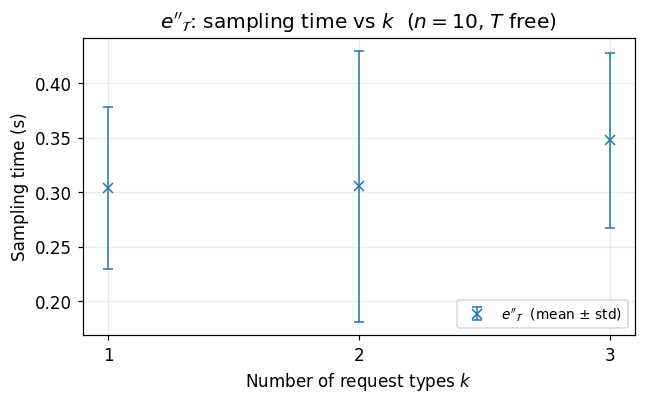

Saved 12_partA_scaling.pdf


In [8]:
import time as _time

K_MAX    = len(DEADLINES_DEMO)
N_REPS   = 100
N_length = 10

k_vals, mean_times, std_times = [], [], []

for k in range(1, K_MAX + 1):
    dl     = DEADLINES_DEMO[:k]
    phi, _ = build_e_dprime(dl)
    dl_str = ", ".join(f"T_{i+1}={T}" for i,(r,T) in enumerate(dl))

    ts = []
    print(f"k={k:2d}  n={N_length}  [{dl_str}]: ", end="", flush=True)
    for _ in range(N_REPS):
        t0 = _time.perf_counter()
        try:
            sample(phi, N_length)
            ts.append(_time.perf_counter() - t0)
        except Exception as e:
            print(f"fail({type(e).__name__}) ", end="")

    if ts:
        m = float(np.mean(ts)); s = float(np.std(ts))
        k_vals.append(k); mean_times.append(m); std_times.append(s)
        print(f"mean={m:.3f}s  std={s:.3f}s")
    else:
        print("all failed")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.errorbar(k_vals, mean_times, yerr=std_times,
            color="#1f77b4", marker="x", markersize=7, lw=0,
            capsize=3, elinewidth=1, label=r"$e''_\mathcal{T}$  (mean $\pm$ std)")
ax.set_xlabel("Number of request types $k$")
ax.set_ylabel("Sampling time (s)")
ax.set_title(f"$e''_\\mathcal{{T}}$: sampling time vs $k$  ($n={N_length}$, $T$ free)")
ax.set_xticks(k_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "12_partA_scaling.pdf"), bbox_inches="tight")
plt.show()
print("Saved 12_partA_scaling.pdf")


### Interpretation

**Volume curves:**
- $k=1$: volume grows from 0, saturates at $T_1$ (constraint becomes non-binding).
- $k=2$: zero below $T_1$, grows as a polynomial, saturates near $T_2$.
- $k=3$: same pattern one level deeper; dotted verticals mark each $T_i$.
- $e'_\mathcal{T}$ ($2k$ events/cycle) and $e''_\mathcal{T}$ (up to $k{+}1$ events/cycle)
  describe related but different languages: $e'_\mathcal{T}$ requires one grant per
  request type, $e''_\mathcal{T}$ uses one shared grant for all present requests.

**Scaling curve ($T_i = i$):**
- Sampling time grows slowly with $k$ (roughly polynomial).
- A TA encoding of $e'_\mathcal{T}$ needs $k$ clocks — exponential state blowup.
  VolTRE's algebraic approach avoids this entirely.

**Nicolas's next step:** run TA sampler for the same expressions at
$k = 5, 10, 15$ and overlay on this plot.
